# 01 · Exploración de datos — IEEE-CIS Fraud Detection

**Objetivo de este notebook:** entender la forma, calidad y señales del dataset antes de tomar
ninguna decisión de limpieza o feature engineering. Todo lo que se decida en `02_limpieza.ipynb`
y `03_feature_engineering.ipynb` debe estar justificado por algo que se observe aquí.

Este notebook es puramente exploratorio: **no se ajusta ni se guarda ningún parámetro** (no hay
imputación, no hay encoding). Solo se cargan los datos crudos de `train_transaction.csv` y
`train_identity.csv`, se hace el merge, y se describen sus propiedades.

Nota: `test_transaction.csv` / `test_identity.csv` (el set de Kaggle para submission) **no tienen
la columna `isFraud`** — no sirven para evaluar modelos de forma supervisada, por lo que quedan
fuera del alcance de este pipeline. El "test" que se usa en el resto de los notebooks es un split
interno derivado de `train_transaction` + `train_identity`.

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
warnings.filterwarnings("ignore")

sys.path.append(str(Path("..").resolve()))
from src.utils import reduce_mem_usage

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

RAW_DIR = Path("../data/raw")
pd.set_option("display.max_columns", 60)


## 1. Carga de datos

Cargamos `train_transaction.csv` y `train_identity.csv` y aplicamos `reduce_mem_usage` justo
después de la carga, ya que estos CSV pesan varios cientos de MB y muchas columnas numéricas
vienen en `int64`/`float64` cuando podrían representarse en tipos mucho más pequeños.

In [2]:
train_transaction = pd.read_csv(RAW_DIR / "train_transaction.csv")
train_transaction = reduce_mem_usage(train_transaction)
print("train_transaction:", train_transaction.shape)


Memoria: 1791.67 MB -> 861.11 MB (reducción del 51.9%)
train_transaction: (590540, 394)


In [3]:
train_identity = pd.read_csv(RAW_DIR / "train_identity.csv")
train_identity = reduce_mem_usage(train_identity)
print("train_identity:", train_identity.shape)


Memoria: 56.51 MB -> 16.01 MB (reducción del 71.7%)
train_identity: (144233, 41)


## 2. Merge por `TransactionID`

No todas las transacciones tienen información de identidad asociada (dispositivo, red, etc.),
por lo que el merge debe ser `left` desde `train_transaction` — cualquier transacción sin match
en `train_identity` conserva sus columnas `id_*`/`DeviceType`/`DeviceInfo` como `NaN` en vez de
perderse.

In [4]:
df = train_transaction.merge(train_identity, on="TransactionID", how="left")
print("df (merge):", df.shape)
print(f"% de transacciones con datos de identity: {df['DeviceType'].notna().mean()*100:.1f}%")

del train_transaction, train_identity


df (merge): (590540, 434)
% de transacciones con datos de identity: 23.8%


## 3. Dimensiones y tipos de datos

Revisamos cuántas columnas hay de cada tipo (numéricas vs categóricas) para tener una idea de
cuánto trabajo de encoding habrá en `02_limpieza.ipynb`.

In [5]:
dtype_counts = df.dtypes.astype(str).value_counts()
print(dtype_counts)
print(f"\nTotal columnas: {df.shape[1]} | Total filas: {df.shape[0]}")


float32     399
category     31
int32         2
int8          1
int16         1
Name: count, dtype: int64

Total columnas: 434 | Total filas: 590540


## 4. Valores faltantes por columna

Con más de 430 columnas, no tiene sentido inspeccionar el missing columna por columna en texto.
En su lugar, resumimos la distribución del % de missing y graficamos las columnas más afectadas.

In [6]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_summary = missing_pct.reset_index()
missing_summary.columns = ["columna", "pct_missing"]

print("Resumen de % de missing por columna:")
print(missing_summary["pct_missing"].describe())

n_cols_over_90 = (missing_pct > 90).sum()
n_cols_over_50 = (missing_pct > 50).sum()
n_cols_no_missing = (missing_pct == 0).sum()
print(f"\nColumnas con >90% missing: {n_cols_over_90}")
print(f"Columnas con >50% missing: {n_cols_over_50}")
print(f"Columnas sin ningún missing: {n_cols_no_missing}")


Resumen de % de missing por columna:
count    434.000000
mean      45.074372
std       36.543232
min        0.000000
25%        0.266282
50%       47.293494
75%       77.913435
max       99.196159
Name: pct_missing, dtype: float64

Columnas con >90% missing: 12
Columnas con >50% missing: 214
Columnas sin ningún missing: 20


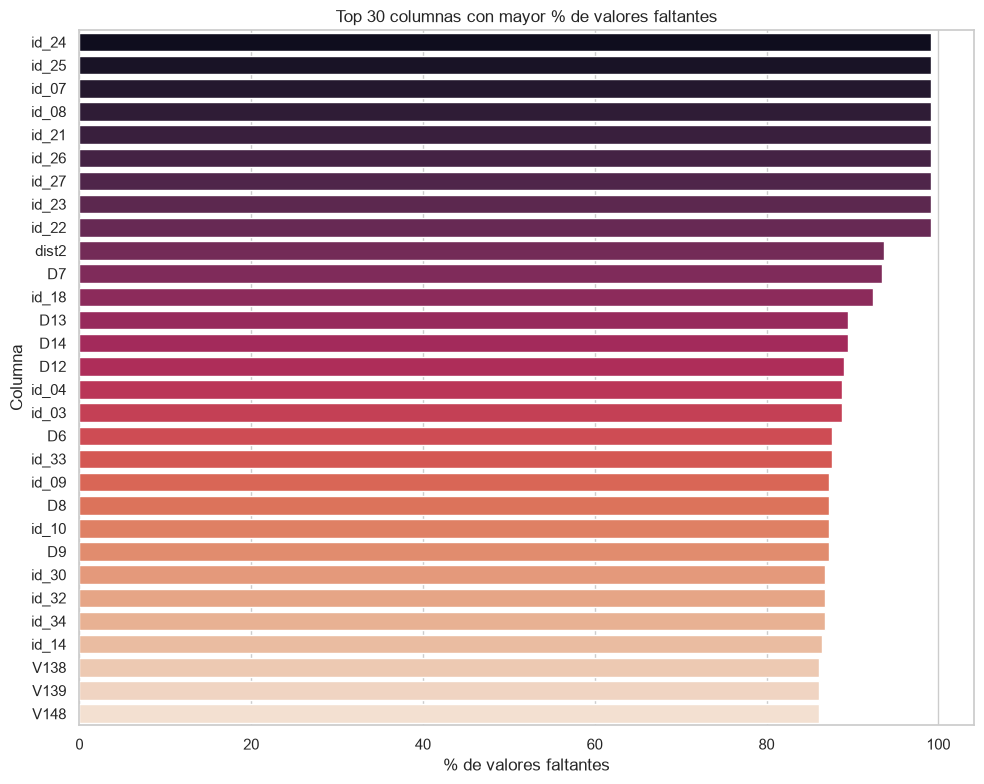

In [7]:
top_missing = missing_summary.head(30)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_missing, y="columna", x="pct_missing", hue="columna", legend=False,
            palette="rocket", ax=ax)
ax.set_title("Top 30 columnas con mayor % de valores faltantes")
ax.set_xlabel("% de valores faltantes")
ax.set_ylabel("Columna")
plt.tight_layout()
plt.show()


## 5. Distribución de la variable objetivo `isFraud`

Este es el punto central del proyecto: el dataset está fuertemente desbalanceado.

isFraud
0    569877
1     20663
Name: count, dtype: int64
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


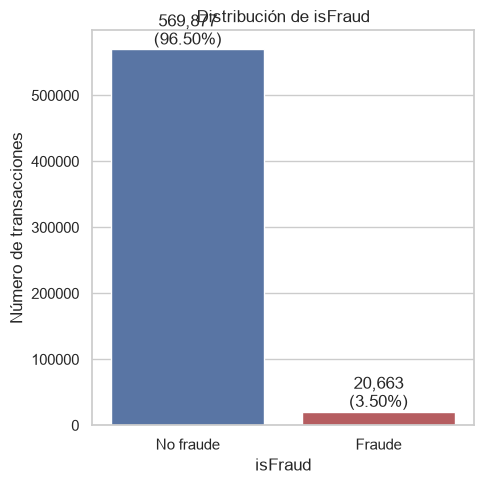

In [8]:
fraud_counts = df["isFraud"].value_counts().sort_index()
fraud_pct = df["isFraud"].value_counts(normalize=True).sort_index() * 100

print(fraud_counts)
print(fraud_pct)

fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(x=fraud_counts.index.map({0: "No fraude", 1: "Fraude"}), y=fraud_counts.values,
            hue=fraud_counts.index, legend=False, palette=["#4C72B0", "#C44E52"], ax=ax)
for i, (count, pct) in enumerate(zip(fraud_counts.values, fraud_pct.values)):
    ax.text(i, count, f"{count:,}\n({pct:.2f}%)", ha="center", va="bottom")
ax.set_title("Distribución de isFraud")
ax.set_ylabel("Número de transacciones")
plt.tight_layout()
plt.show()


**Conclusión parcial:** ~3.5% de las transacciones son fraude. Cualquier modelo entrenado sin
tratar el desbalance tenderá a predecir siempre "no fraude" y aun así lograr >96% de accuracy,
por eso accuracy no es una métrica útil aquí — se prioriza AUC-ROC, AUPRC, F1, precisión y recall
(ver `05_modelo.ipynb`).

## 6. `TransactionAmt`: monto de la transacción

count    590540.000000
mean        135.027176
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64


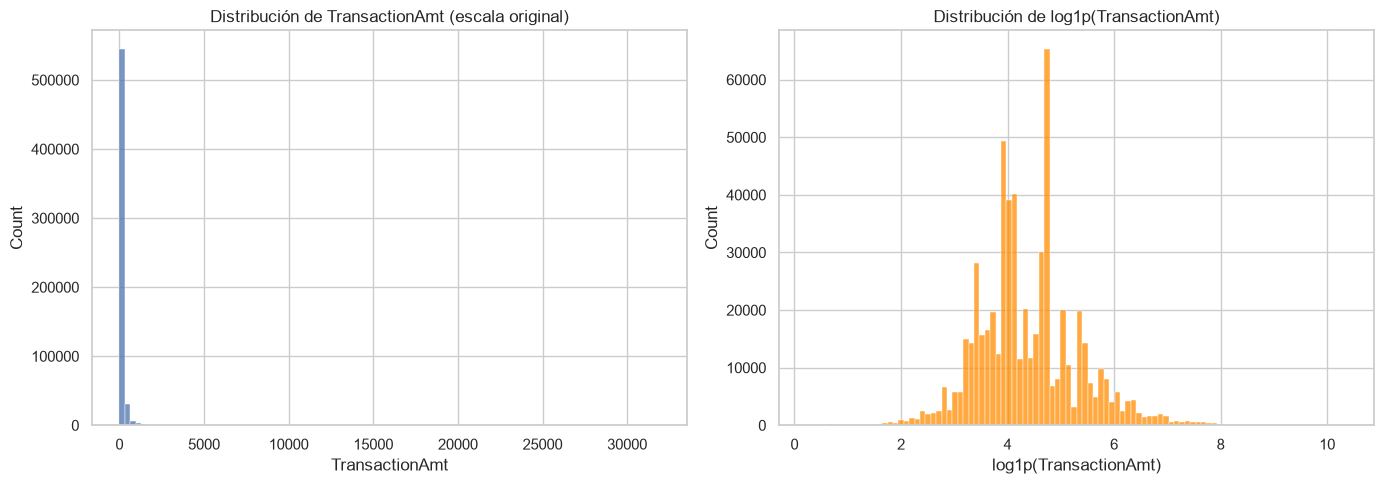

In [9]:
print(df["TransactionAmt"].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["TransactionAmt"], bins=100, ax=axes[0])
axes[0].set_title("Distribución de TransactionAmt (escala original)")
axes[0].set_xlabel("TransactionAmt")

sns.histplot(np.log1p(df["TransactionAmt"]), bins=100, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de log1p(TransactionAmt)")
axes[1].set_xlabel("log1p(TransactionAmt)")
plt.tight_layout()
plt.show()


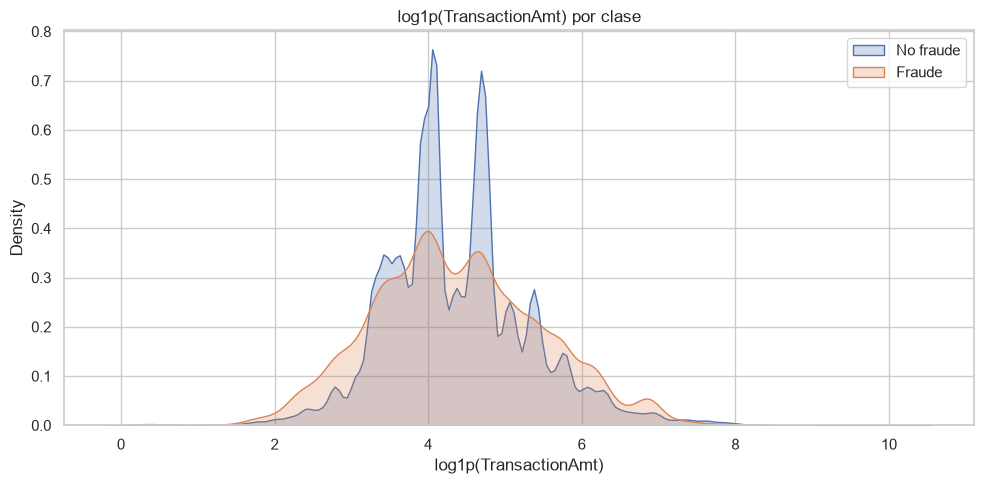

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(np.log1p(df.loc[df["isFraud"] == 0, "TransactionAmt"]), label="No fraude", fill=True, ax=ax)
sns.kdeplot(np.log1p(df.loc[df["isFraud"] == 1, "TransactionAmt"]), label="Fraude", fill=True, ax=ax)
ax.set_title("log1p(TransactionAmt) por clase")
ax.set_xlabel("log1p(TransactionAmt)")
ax.legend()
plt.tight_layout()
plt.show()


`TransactionAmt` tiene una distribución muy sesgada a la derecha (long tail) → `log1p` la hace
mucho más manejable, lo cual es útil sobre todo para la regresión logística. Se observa además
que los montos de fraude no se concentran únicamente en valores altos, lo que sugiere que el
monto por sí solo no separa bien las clases y hay que apoyarse en más features.

## 7. `ProductCD`: tasa de fraude por tipo de producto

           n_transacciones  tasa_fraude
ProductCD                              
C                    68519     0.116873
S                    11628     0.058996
H                    33024     0.047662
R                    37699     0.037826
W                   439670     0.020399


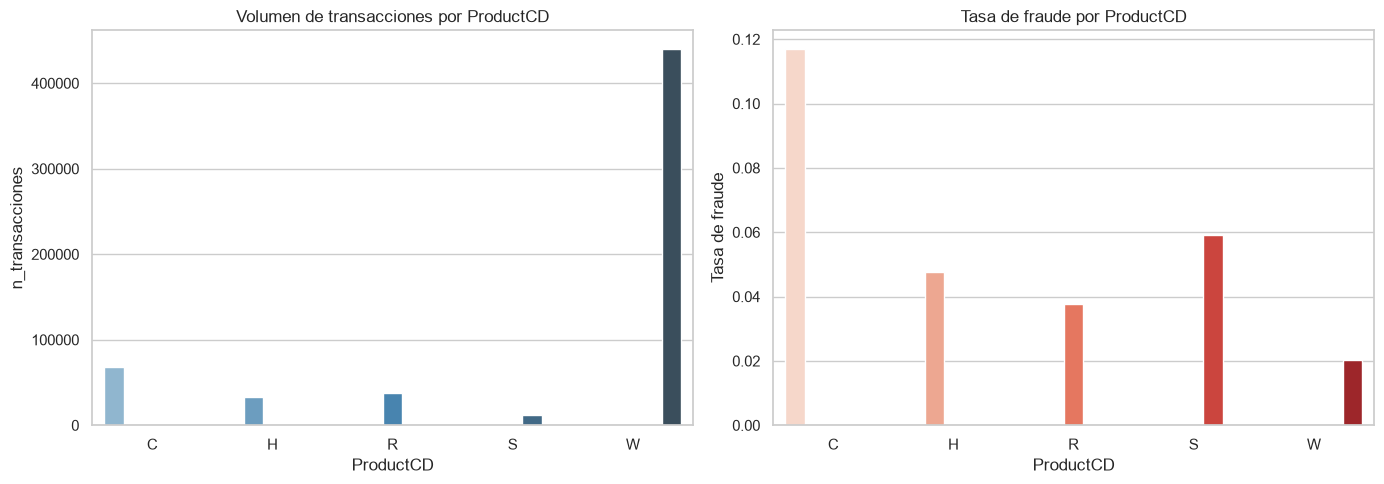

In [11]:
product_stats = df.groupby("ProductCD", observed=True)["isFraud"].agg(["count", "mean"])
product_stats.columns = ["n_transacciones", "tasa_fraude"]
product_stats = product_stats.sort_values("tasa_fraude", ascending=False)
print(product_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=product_stats.reset_index(), x="ProductCD", y="n_transacciones",
            hue="ProductCD", legend=False, palette="Blues_d", ax=axes[0])
axes[0].set_title("Volumen de transacciones por ProductCD")

sns.barplot(data=product_stats.reset_index(), x="ProductCD", y="tasa_fraude",
            hue="ProductCD", legend=False, palette="Reds", ax=axes[1])
axes[1].set_title("Tasa de fraude por ProductCD")
axes[1].set_ylabel("Tasa de fraude")
plt.tight_layout()
plt.show()


## 8. `card4` (marca de tarjeta) y `card6` (tipo de tarjeta)

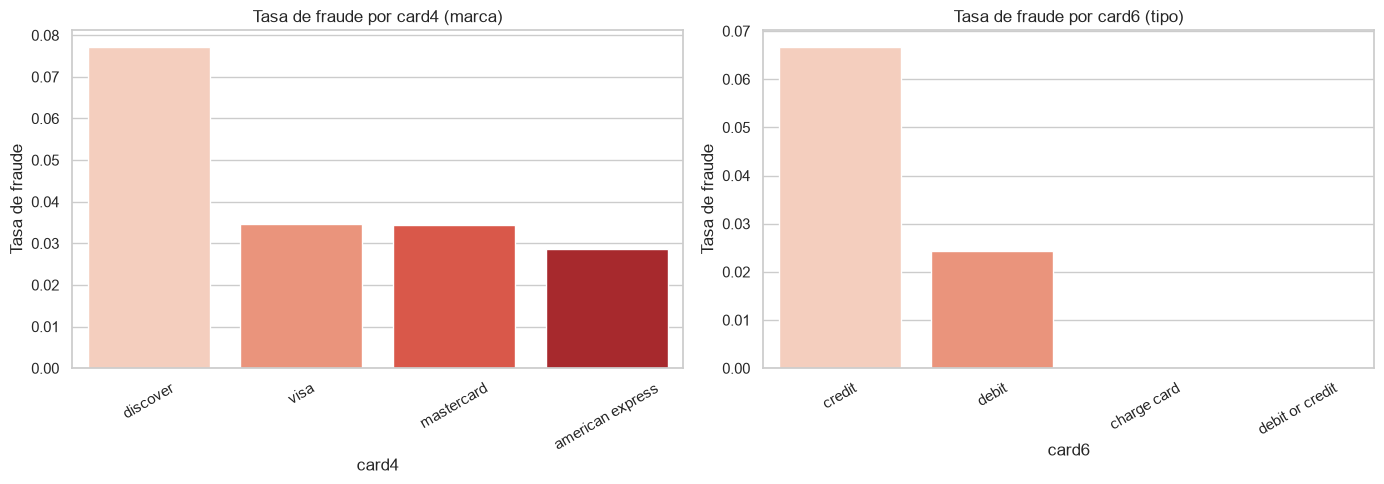

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

card4_stats = df.groupby("card4", observed=True)["isFraud"].mean().sort_values(ascending=False)
sns.barplot(x=card4_stats.index.astype(str), y=card4_stats.values, hue=card4_stats.index.astype(str),
            legend=False, palette="Reds", ax=axes[0])
axes[0].set_title("Tasa de fraude por card4 (marca)")
axes[0].set_ylabel("Tasa de fraude")
axes[0].tick_params(axis="x", rotation=30)

card6_stats = df.groupby("card6", observed=True)["isFraud"].mean().sort_values(ascending=False)
sns.barplot(x=card6_stats.index.astype(str), y=card6_stats.values, hue=card6_stats.index.astype(str),
            legend=False, palette="Reds", ax=axes[1])
axes[1].set_title("Tasa de fraude por card6 (tipo)")
axes[1].set_ylabel("Tasa de fraude")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 9. Distribución temporal (`TransactionDT`)

`TransactionDT` **no es un timestamp real**, es un contador de segundos desde un punto de
referencia arbitrario (según la documentación de la competencia). El rango cubre unos 6 meses de
datos. No podemos convertirlo a fecha calendario real, pero sí podemos derivar hora del día y día
relativo mediante aritmética modular — eso se explota más a fondo en `03_feature_engineering.ipynb`.

Rango de TransactionDT: 86400 - 15811131
Duración aproximada: 181 días


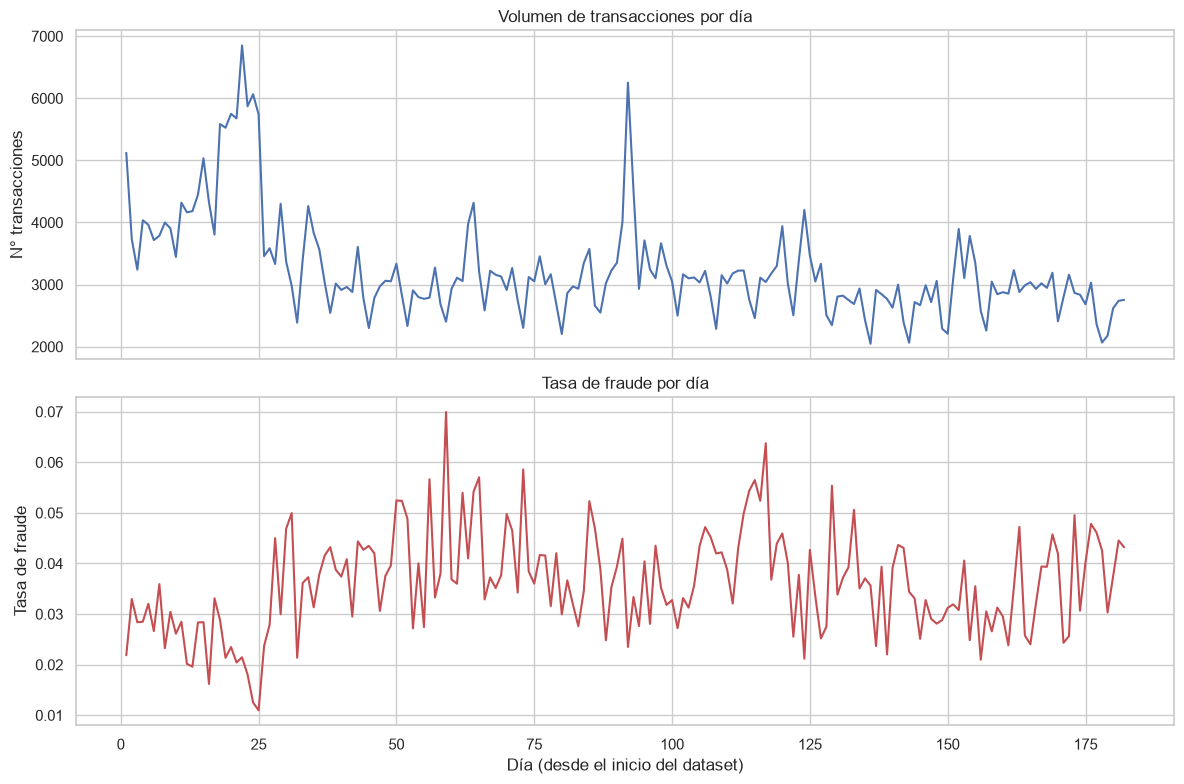

In [13]:
SECONDS_PER_DAY = 24 * 60 * 60
df["_day"] = (df["TransactionDT"] // SECONDS_PER_DAY).astype(int)
df["_hour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)

print(f"Rango de TransactionDT: {df['TransactionDT'].min()} - {df['TransactionDT'].max()}")
print(f"Duración aproximada: {df['_day'].max() - df['_day'].min()} días")

daily = df.groupby("_day").agg(n_transacciones=("isFraud", "size"), tasa_fraude=("isFraud", "mean"))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(daily.index, daily["n_transacciones"], color="#4C72B0")
axes[0].set_title("Volumen de transacciones por día")
axes[0].set_ylabel("N° transacciones")

axes[1].plot(daily.index, daily["tasa_fraude"], color="#C44E52")
axes[1].set_title("Tasa de fraude por día")
axes[1].set_ylabel("Tasa de fraude")
axes[1].set_xlabel("Día (desde el inicio del dataset)")

plt.tight_layout()
plt.show()


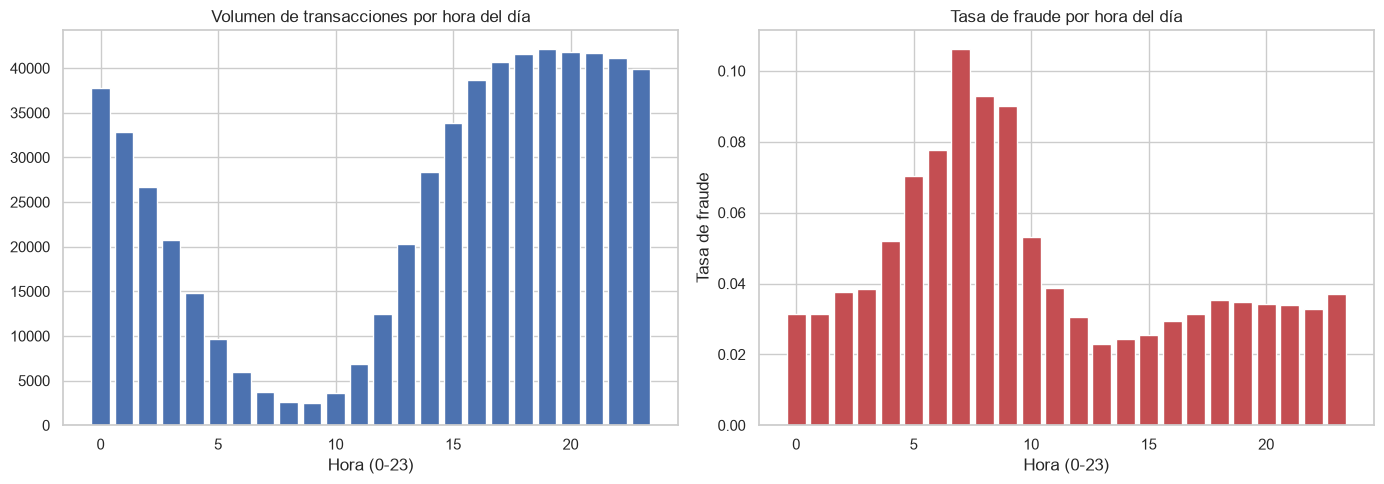

In [14]:
hourly_fraud = df.groupby("_hour")["isFraud"].agg(["size", "mean"])
hourly_fraud.columns = ["n_transacciones", "tasa_fraude"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(hourly_fraud.index, hourly_fraud["n_transacciones"], color="#4C72B0")
axes[0].set_title("Volumen de transacciones por hora del día")
axes[0].set_xlabel("Hora (0-23)")

axes[1].bar(hourly_fraud.index, hourly_fraud["tasa_fraude"], color="#C44E52")
axes[1].set_title("Tasa de fraude por hora del día")
axes[1].set_xlabel("Hora (0-23)")
axes[1].set_ylabel("Tasa de fraude")
plt.tight_layout()
plt.show()

df.drop(columns=["_day", "_hour"], inplace=True)


Se observa un patrón horario claro: el volumen de transacciones baja durante la madrugada, pero
la **tasa de fraude sube** justo en esas horas de bajo volumen — un patrón muy citado en la
literatura de detección de fraude (menos supervisión/actividad legítima de fondo). Esto justifica
extraer `hora del día` como feature explícita en `03_feature_engineering.ipynb`.

## 10. Conclusiones y decisiones para los siguientes notebooks

- **Desbalance:** ~3.5% de fraude → se usará AUC-ROC, AUPRC, F1, precisión y recall (no accuracy)
  como métricas principales, y se probará balanceo de clases (`04_balanceo.ipynb`).
- **Missing values:** hay un grupo grande de columnas (sobre todo `id_*` y varias `V*`) con más
  del 90% de missing → se usará ese umbral para eliminarlas en `02_limpieza.ipynb`. Para las
  columnas con missing moderado, la estrategia de imputación debe diferenciar numéricas de
  categóricas.
- **`TransactionAmt`:** distribución muy sesgada → conviene trabajar con `log1p(TransactionAmt)`
  además de la parte decimal (centavos), que se explora en `03_feature_engineering.ipynb`.
- **`ProductCD`, `card4`, `card6`:** todas muestran tasas de fraude claramente distintas entre
  categorías → son buenas variables categóricas a codificar y conservar.
- **`TransactionDT`:** no es una fecha real, pero la hora del día derivada muestra una relación
  clara con la tasa de fraude → se extraerán features de hora/día en `03_feature_engineering.ipynb`.
- El set de Kaggle `test_transaction.csv`/`test_identity.csv` no tiene `isFraud` y queda fuera del
  pipeline de evaluación; el "test" usado de aquí en adelante es un split interno estratificado.